# APR Pixel Reassignment

Applies **Adaptive Pixel Reassignment (APR)** to a calibrated BrightEyes MCS `.h5` file,
then saves the result as a current-schema output run such as `/output/apr_001`.


In [1]:
from pathlib import Path
import sys

# Walk up from the current directory until the project root (containing "src") is found
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

# Also add BrightEyes-MCS-File if it lives next to the project root
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from brighteyes_mcs_file import H5OutputProduct, write_h5_output_run

import brighteyes_ism.analysis.APR_lib as apr   # shift-vector computation and reassignment
import brighteyes_ism.analysis.Graph_lib as gr  # shift-vector visualisation



## Parameters

Edit only this cell before running the notebook.

| Parameter | Description |
|---|---|
| `FILE_DATA` | Path to the calibrated BrightEyes MCS `.h5` file |
| `OUTPUT_RUN_ID` | Output run id under `/output`, usually `apr_001` |
| `OUTPUT_MODE` | `append`, `copy`, or `outputs_only` |
| `FILE_OUTPUT` | Optional output path for `copy` or `outputs_only`; ignored for `append` |
| `OUTPUT_KEY_OVERWRITE` | If `True`, replace `/output/<OUTPUT_RUN_ID>`; if `False`, auto-version to the next suffix |
| `ROI` | Pixel crop `(row_start, row_end, col_start, col_end)` applied to `image[0, 0, ...]`; set to `None` to keep the full field of view |
| `REF_CHANNEL` | Index of the central detector element used as the reassignment reference (typically 12 for a 5x5 array) |
| `USF` | Up-sampling factor for sub-pixel shift estimation (higher = more accurate but slower) |
| `REASSIGN_MODE` | `'interp'` for bilinear interpolation (recommended), `'fft'` for Fourier-shift |


In [2]:
# Path to the calibrated BrightEyes MCS file
FILE_DATA = r'/home/morlando1-iit.local/manuel/18052026_flim/Convallaria_calib.h5'

# Output run configuration
OUTPUT_RUN_ID = "apr_001"
OUTPUT_MODE = "append"  # append, copy, or outputs_only
FILE_OUTPUT = None      # optional path for copy or outputs_only
OUTPUT_KEY_OVERWRITE = False

# Spatial crop applied to image[0, 0, ...] as (row_start, row_end, col_start, col_end)
# Set to None to skip cropping and keep the full field of view
ROI = None  # (1000, 1750, 1200, 1950)

# Index of the central detector element (reference for shift estimation)
REF_CHANNEL = 12

# Sub-pixel up-sampling factor for shift vector estimation
USF = 100

# Pixel-reassignment interpolation mode: 'interp' (bilinear) or 'fft'
REASSIGN_MODE = "interp"


FILE_DATA = '/mnt/DATA/Mixed Data/Giuse2/Test_01_large_DFD_calib.h5'


## Step 1 - Load the calibrated SPAD data and estimate shift vectors

Shift vectors are computed on the **intensity image** (sum over time bins), because
the spatial offset of each detector element is time-independent.
Summing all bins maximises the SNR and makes the estimation more robust.


Cropped image shape (y, x, t_bins, channels): (512, 512, 91, 25)
Intensity image shape (y, x, channels):         (512, 512, 25)

Shift vectors (one row per channel, columns = [dy, dx]):
[[-1.18 -0.65]
 [-1.01 -0.13]
 [-0.87  0.43]
 [-0.68  0.95]
 [-0.46  1.47]
 [-0.79 -0.86]
 [-0.62 -0.32]
 [-0.43  0.21]
 [-0.26  0.73]
 [-0.09  1.26]
 [-0.34 -1.05]
 [-0.17 -0.53]
 [ 0.    0.  ]
 [ 0.16  0.54]
 [ 0.32  1.07]
 [ 0.07 -1.23]
 [ 0.26 -0.74]
 [ 0.42 -0.2 ]
 [ 0.57  0.33]
 [ 0.74  0.86]
 [ 0.49 -1.4 ]
 [ 0.68 -0.92]
 [ 0.83 -0.41]
 [ 1.    0.13]
 [ 1.17  0.67]]


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


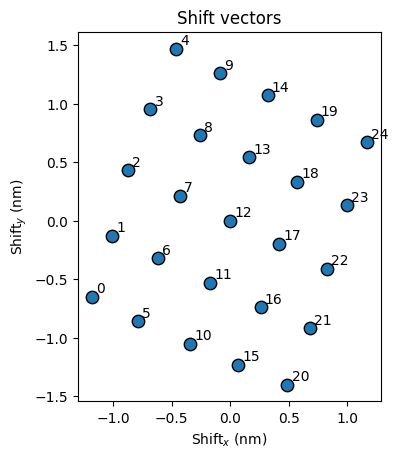

In [3]:
with h5py.File(FILE_DATA, "r") as f:
    if "raw/spad" in f:
        source_data_path = "/raw/spad"
        raw = f["raw/spad"]
    elif "data" in f:
        source_data_path = "/data"
        raw = f["data"]
    else:
        raise KeyError("Expected /raw/spad or legacy /data in FILE_DATA")

    source_axis_order = raw.attrs.get(
        "axis_order",
        "repetition,z,y,x,time_bin,detector_channel",
    )

    # Raw data shape: (repetitions, z_planes, y, x, t_bins, channels)
    image_4D = raw[0, 0, ...]

    # Apply the spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]   # (y_crop, x_crop, t_bins, channels)

    print(f"Cropped image shape (y, x, t_bins, channels): {image_4D.shape}")

# Collapse the time axis to obtain a pure intensity image (y, x, channels).
# This is used ONLY for shift-vector estimation; the full 4-D array is kept intact.
image_intensity = np.sum(image_4D, axis=-2)
print(f"Intensity image shape (y, x, channels):         {image_intensity.shape}")

# Estimate sub-pixel shift vectors between each channel and the reference detector.
# shift_vectors: (n_channels, 2) array - one (dy, dx) pair per channel
shift_vectors, estimation_error = apr.ShiftVectors(image_intensity, usf=USF, ref=REF_CHANNEL)

print("\nShift vectors (one row per channel, columns = [dy, dx]):")
print(shift_vectors)

# Visualise the shift vectors on a grid plot
gr.PlotShiftVectors(shift_vectors)
plt.show()


## Step 2 - Apply pixel reassignment bin by bin and save `/output/<run_id>`

The reassignment is applied **separately to each time bin** so that photon
arrival-time information (needed for FLIM/phasor analysis) is fully preserved.

The output is saved as `/output/<run_id>/products/spad`. The APR shift vectors
are saved in `/output/<run_id>/intermediates/shift_vectors` and referenced from
the APR metadata.


In [4]:
n_y, n_x, n_bins, n_ch = image_4D.shape
dataset_shape = (1, 1, n_y, n_x, n_bins, n_ch)
apr_data = np.empty(dataset_shape, dtype=np.float32)

# Main loop: apply reassignment independently for each time bin.
# image_4D[:, :, b, :] -> shape (y, x, channels)
# apr.Reassignment returns the spatially-shifted (y, x, channels) array.
for b in tqdm(range(n_bins), desc="Reassigning time bins"):
    reassigned_bin = apr.Reassignment(
        shift_vectors,
        image_4D[:, :, b, :],
        mode=REASSIGN_MODE,
    )
    apr_data[0, 0, :, :, b, :] = reassigned_bin

shift_vectors_path = "/output/{run_id}/intermediates/shift_vectors"
roi = [] if ROI is None else list(ROI)

FILE_RESULT, APR_RUN_ID = write_h5_output_run(
    FILE_DATA,
    OUTPUT_RUN_ID,
    [
        H5OutputProduct(
            "spad",
            apr_data,
            attrs={
                "units": "counts",
                "long_name": "APR-reassigned SPAD digital detector counts",
                "axis_order": source_axis_order,
                "source_data_path": source_data_path,
                "source_metadata_path": "/raw/metadata",
                "source_channel_axis": -1,
                "description": "SPAD data after Adaptive Pixel Reassignment.",
            },
        )
    ],
    mode=OUTPUT_MODE,
    output_path=FILE_OUTPUT,
    output_key_overwrite=OUTPUT_KEY_OVERWRITE,
    output_type="image_tool",
    tool_name="APR reassignment",
    algorithm_name="adaptive_pixel_reassignment",
    attrs={
        "source_data_path": source_data_path,
        "output_data_path": "/output/{run_id}/products/spad",
        "input_axis_order": source_axis_order,
        "output_axis_order": source_axis_order,
        "shift_vectors_path": shift_vectors_path,
    },
    inputs={
        "source_data_path": source_data_path,
        "input_axis_order": source_axis_order,
        "roi_json": roi,
    },
    metadata={
        "source_data_path": source_data_path,
        "source_metadata_path": "/raw/metadata",
        "shift_vectors_path": shift_vectors_path,
        "roi_json": roi,
    },
    parameters={
        "ref_channel": REF_CHANNEL,
        "usf": USF,
        "reassign_mode": REASSIGN_MODE,
        "roi_json": roi,
        "estimation_error_json": np.asarray(estimation_error).tolist(),
    },
    intermediates=[
        H5OutputProduct(
            "shift_vectors",
            np.asarray(shift_vectors, dtype=np.float64),
            attrs={
                "axes": "detector_channel,shift_component",
                "shift_components_json": ["dy", "dx"],
                "reference_channel": REF_CHANNEL,
                "usf": USF,
            },
        )
    ],
)

print(f"\nAPR output saved to:\n  {FILE_RESULT}")
print(f"APR run id: {APR_RUN_ID}")
print(f"Output dataset shape: {dataset_shape}  (rep, z, y, x, t_bins, channels)")


Reassigning time bins: 100%|██████████| 91/91 [01:11<00:00,  1.28it/s]



APR output saved to:
  /mnt/DATA/Mixed Data/Giuse2/Test_01_large_DFD_calib.h5
APR run id: apr_001
Output dataset shape: (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


## Step 3 — Quick sanity check

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.

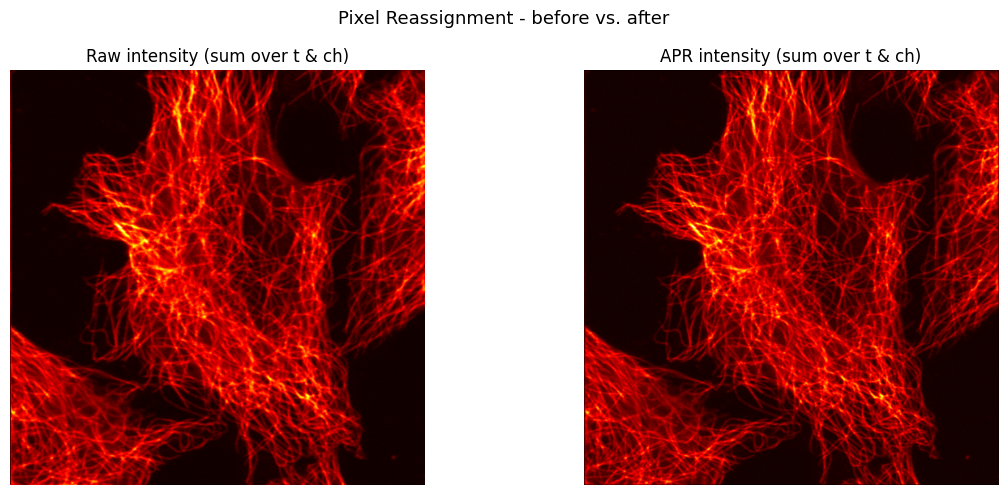

Raw image - min: 17  max: 2037
APR image - min: 5.0  max: 2259.0


In [5]:
with h5py.File(FILE_RESULT, "r") as f_out:
    data_apr = f_out[f"output/{APR_RUN_ID}/products/spad"][0, 0, ...]   # (y, x, t_bins, channels)

# Collapse t_bins and channels -> 2-D intensity maps
intensity_apr = np.sum(data_apr, axis=(-2, -1))
intensity_raw = np.sum(image_4D, axis=(-2, -1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(intensity_raw, cmap="hot", origin="lower")
axes[0].set_title("Raw intensity (sum over t & ch)")
axes[0].axis("off")

axes[1].imshow(intensity_apr, cmap="hot", origin="lower")
axes[1].set_title("APR intensity (sum over t & ch)")
axes[1].axis("off")

fig.suptitle("Pixel Reassignment - before vs. after", fontsize=13)
fig.tight_layout()
plt.show()

print(f"Raw image - min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
print(f"APR image - min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")


## Next step

The APR result is available at:

```python
output_path = f"/output/{APR_RUN_ID}/products/spad"
```

Use `FILE_RESULT` as the HDF5 file path and `APR_RUN_ID` as the selected output run.


In [6]:
import importlib
import brighteyes_mcs_file

importlib.reload(brighteyes_mcs_file)

from brighteyes_mcs_file import show_h5_structure_html

In [7]:

from brighteyes_mcs_file import show_h5_structure_html
show_h5_structure_html(FILE_RESULT)

'<script>\n(function () {\n  // Expand / collapse ALL groups in the widget\n  function h5All(widgetId, open) {\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'details.h5-branch\').forEach(function(d) {\n      d.open = open;\n    });\n  }\n\n  // Expand / collapse all groups at a specific depth inside a widget\n  function h5LevelToggle(widgetId, depth, open, btn) {\n    // Stop the click from toggling the parent <details>\n    if (btn) { btn.closest(\'details\') && (event || window.event) && (event || window.event).stopPropagation(); }\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'li.h5-li-group[data-depth="\' + depth + \'"]\').forEach(function(li) {\n      var det = li.querySelector(\':scope > details.h5-branch\');\n      if (det) det.open = open;\n    });\n  }\n\n  // Expose globally so onclick= attributes work\n  window.h5All = h5All;\n  window.h5LevelToggle = h5LevelTogg